# Self-Organizing Maps (SOMs) Notebook - Alaska Cyclones
## Plot timeseries of annual Arctic SIA as well as Alaska/Pacific regional data

**Notebook by Alice DuVivier - June 2026**

In [1]:
import pandas as pd
from glob import glob
import xarray as xr
import numpy as np
import pandas as pd
import cftime
from itertools import product
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from datetime import timedelta
from itertools import product
import cmocean
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mtick

## Load data
- whole Arctic

### Get grid data

In [2]:
# load grid files for plotting

dir_grid = '/glade/u/home/duvivier/masks/'
file_in = 'POP_tx0.1v3_grid.nc'
ds_grid = xr.open_mfdataset(dir_grid+file_in, decode_times=False)    

# clip global data to match other files - do in two steps because that's how I originally clipped data
# Step 1: clip to full Arctic Region
ds_grid_sub = ds_grid.isel(nlat=slice(1750,2400))
# Step 2: clip Arctic Region to Pacific sector only
#ds_grid_sub = ds_grid_sub.isel(nlon=slice(2500,3250))

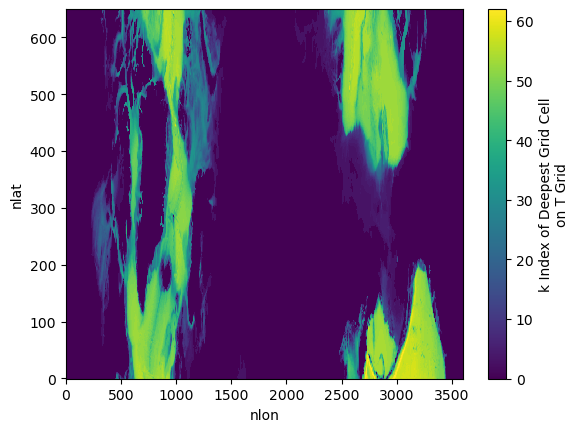

In [3]:
ds_grid_sub.KMT.plot()

In [4]:
# grab lat and lon data
lat2d = ds_grid_sub.TLAT
lon2d = ds_grid_sub.TLONG
tarea = ds_grid_sub.TAREA

In [5]:
# convert tarea to km2 from m2
tarea = tarea/(1000 * 1000)

### Get MESACLIP SIC data
- monthly data by decade

In [6]:
# set path where the som finalist files are
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/SOM_alaska_cyclones/mesaclip_validation/'

In [7]:
fin = 'mesaclip_sia_integrated_arctic.nc'

In [8]:
ds_mesaclip = xr.open_dataset(dir_in + fin)

In [9]:
sia_tot_all = ds_mesaclip.SIA

In [10]:
sia_tot_all

<xarray.DataArray 'SIA' (member_id: 9, time: 2220)> Size: 160kB
[19980 values with dtype=float64]
Coordinates:
  * time     (time) object 18kB 1920-01-16 12:00:00 ... 2104-12-16 12:00:00
Dimensions without coordinates: member_id
Attributes:
    units:      km2
    long_name:  NH total sea ice area (SIA) by month

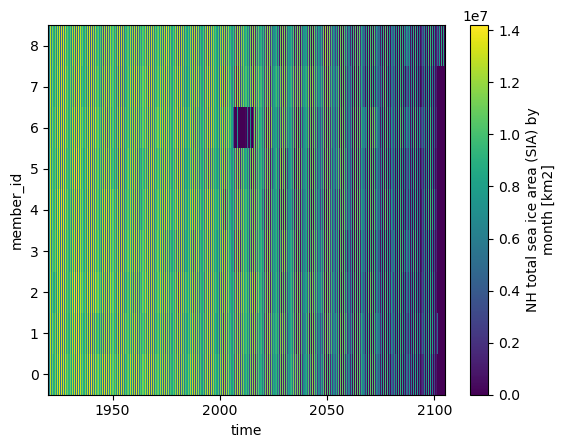

In [11]:
sia_tot_all.plot()

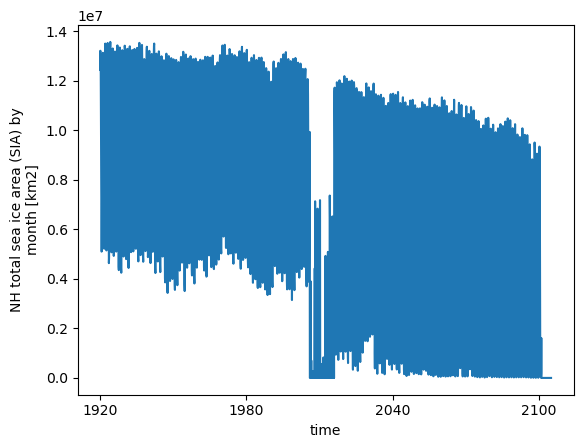

In [12]:
sia_tot_all.isel(member_id=6).plot()

In [13]:
# deal with missing data in a single ensemble member
sia_tot_masked = sia_tot_all.where(sia_tot_all.member_id != 6)

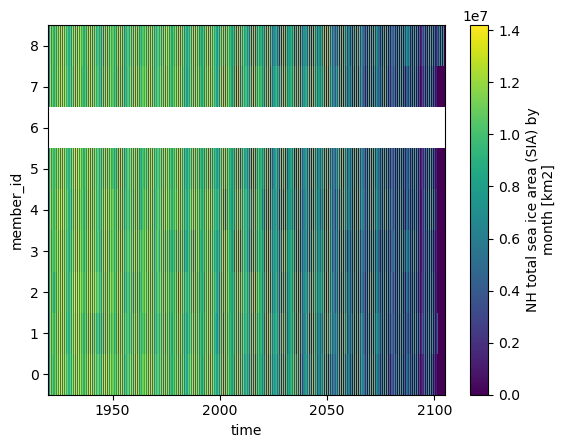

In [14]:
sia_tot_masked.plot()

### Get annual mean, march, september

In [15]:
# get the months of interest
sia_tot_mar = sia_tot_masked.sel(time=sia_tot_masked.time.dt.month == 3)
sia_tot_sep = sia_tot_masked.sel(time=sia_tot_masked.time.dt.month == 9)

In [16]:
# get annual mean
sia_tot_ann = sia_tot_masked.resample(time='YE').mean()

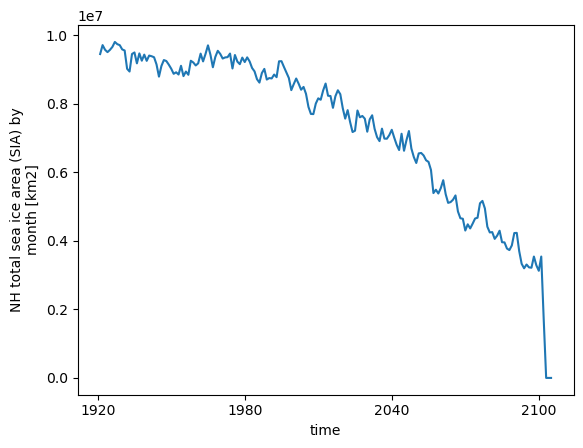

In [17]:
sia_tot_ann.isel(member_id=7).plot()

## Get CDR satellite SIC data
- daily NH data on 25km x 25km grid

In [18]:
dir_in = '/glade/campaign/cesm/development/pcwg/ssmi/CDR/'
file_in = 'cdr_seaice_conc_daily_nh.cdr.noleap.19790101-20211231.nc'

In [19]:
ds_cdr = xr.open_dataset(dir_in + file_in)

In [20]:
ds_cdr.time

<xarray.DataArray 'time' (time: 15695)> Size: 63kB
array([138061., 138062., 138063., ..., 153764., 153765., 153766.],
      dtype=float32)
Coordinates:
  * time     (time) float32 63kB 1.381e+05 1.381e+05 ... 1.538e+05 1.538e+05

In [21]:
# make array of the dates
#dates = pd.date_range(start="1979-01-01", end="2021-12-31", freq="D")
dates_noleap = xr.cftime_range(start="1979-01-01", end="2021-12-31", freq="D", calendar="noleap")
print(len(dates_noleap))

15695


/glade/derecho/scratch/duvivier/tmp/ipykernel_2628/1032269101.py:3: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  dates_noleap = xr.cftime_range(start="1979-01-01", end="2021-12-31", freq="D", calendar="noleap")


In [22]:
# reassign the polynya time array
ds_cdr['time'] = dates_noleap
ds_cdr['time'] = dates_noleap

In [23]:
ds_cdr.time

<xarray.DataArray 'time' (time: 15695)> Size: 126kB
array([cftime.DatetimeNoLeap(1979, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1979, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1979, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2021, 12, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 12, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 126kB 1979-01-01 00:00:00 ... 2021-12-31 00:00:00

In [24]:
# create monthly averages from the daily data
ds_cdr_monthly = ds_cdr.resample(time='ME').mean()

In [25]:
ds_cdr_monthly.time

<xarray.DataArray 'time' (time: 516)> Size: 4kB
array([cftime.DatetimeNoLeap(1979, 1, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1979, 2, 28, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1979, 3, 31, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2021, 10, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 11, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 4kB 1979-01-31 00:00:00 ... 2021-12-31 00:00:00

In [26]:
# save only variable of interest and divide by 100 to get on a 0-1 range
ds_cdr_monthly = ds_cdr_monthly.cdr_seaice_conc_daily
ds_cdr_monthly = ds_cdr_monthly/100

### Calculate the NH total ice area
 - on25 km x 25km EASE grid

In [27]:
# multiply timeseries by tarea and then sum over idim/jdim
sia_tot_cdr = (ds_cdr_monthly * (25 * 25) ).sum(dim=['jdim','idim'])

### Get annual mean, march, september

In [28]:
# get the months of interest
sia_tot_cdr_mar = sia_tot_cdr.sel(time=sia_tot_cdr.time.dt.month == 3)
sia_tot_cdr_sep = sia_tot_cdr.sel(time=sia_tot_cdr.time.dt.month == 9)

In [29]:
# get annual mean
sia_tot_cdr_ann = sia_tot_cdr.resample(time='YE').mean()

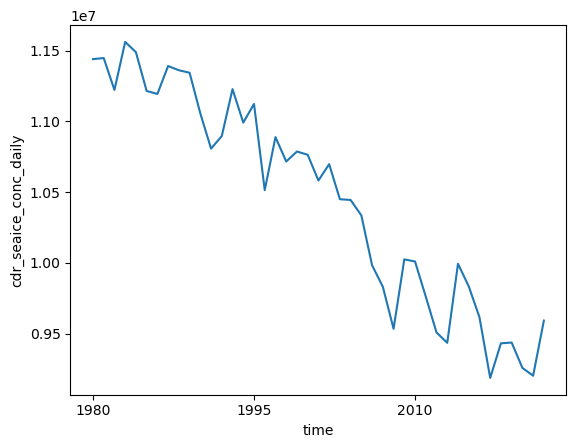

In [30]:
sia_tot_cdr_ann.plot()

## Plot Timeseries to compare

In [31]:
# set output directory
dir_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/SOM_alaska_cyclones/analysis_v2/'

In [32]:
# set x values against which to plot
xarr_cdr = sia_tot_cdr_ann.time.dt.year.values
xarr_mesaclip = sia_tot_ann.time.dt.year.values

In [33]:
# number of ensembles in mesaclip
nens = len(sia_tot_ann.member_id)
print(nens)

9


In [34]:
# divide both datasets by 10^6 to get millions of km2
sia_tot_ann = sia_tot_ann/1000000
sia_tot_mar = sia_tot_mar/1000000
sia_tot_sep = sia_tot_sep/1000000

sia_tot_cdr_ann = sia_tot_cdr_ann/1000000
sia_tot_cdr_mar = sia_tot_cdr_mar/1000000
sia_tot_cdr_sep = sia_tot_cdr_sep/1000000

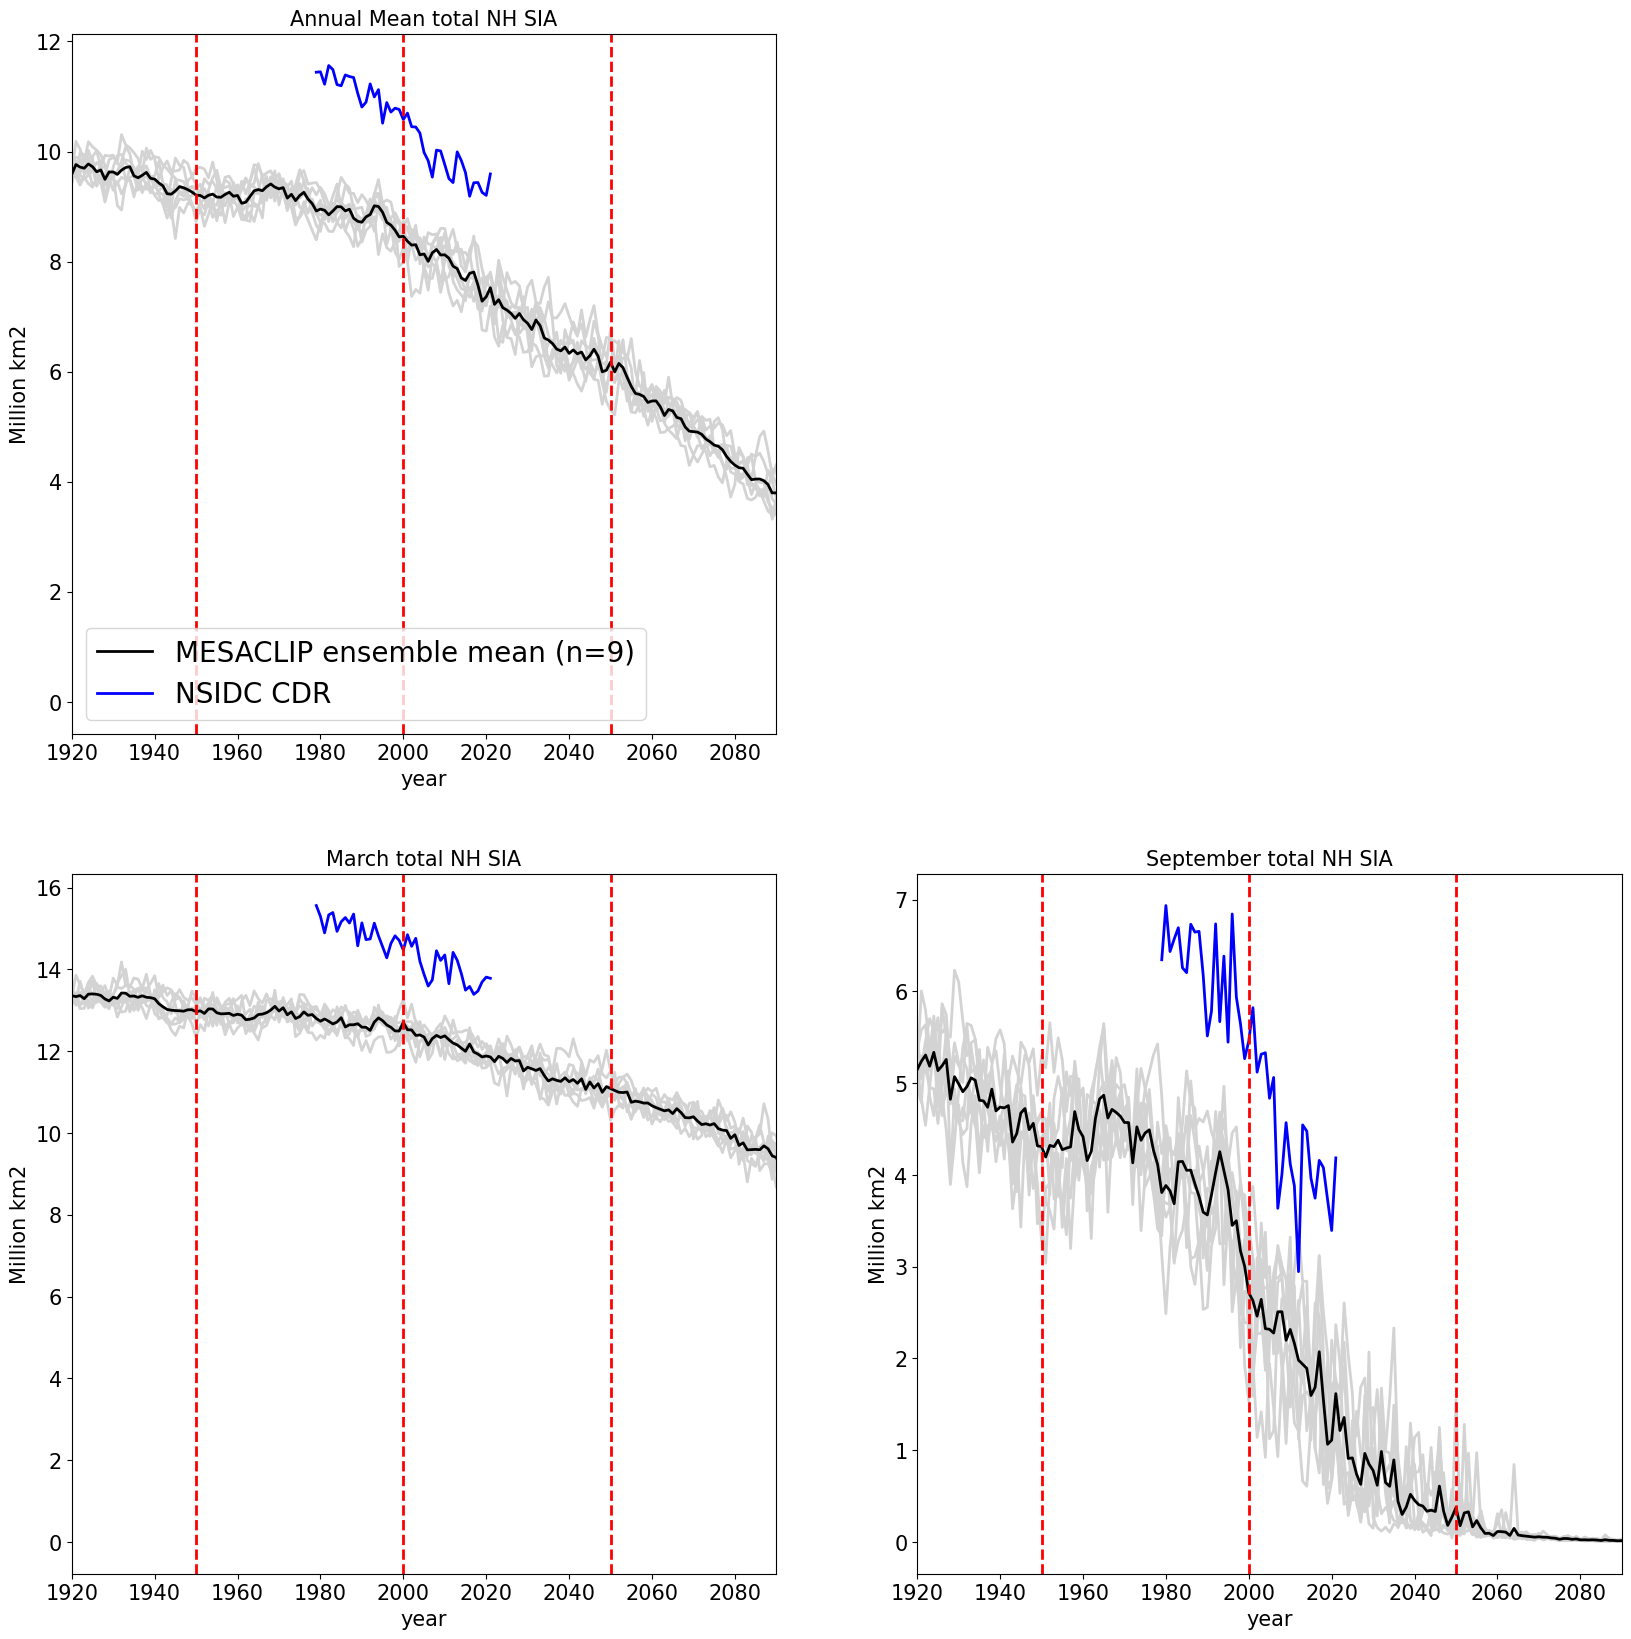

In [35]:
# create figure
fig = plt.figure(figsize=(20,20))
# now loop through months to create subpanels
fout = 'mesaclip_nh_timeseries_annual_mean'

# Make subplot - note it's nrow x ncol x index (starting upper left)
ax = fig.add_subplot(2,2,1)
# plot the mesaclip members
for ii in range(nens):
    ax.plot(xarr_mesaclip,sia_tot_ann.isel(member_id=ii),color="lightgrey",linestyle='-',linewidth=2,label='_nolegend_');
# plot ensemble means
ax.plot(xarr_mesaclip,sia_tot_ann.mean(dim='member_id'),label="MESACLIP ensemble mean (n=9)",color='black',linestyle='-',linewidth=2)
# plot the observations
ax.plot(xarr_cdr,sia_tot_cdr_ann,label="NSIDC CDR",color='blue',linestyle='-',linewidth=2)
# add lines at 1950, 2000, 2050
plt.axvline(x=1950, color='red', linestyle='--', linewidth=2)
plt.axvline(x=2000, color='red', linestyle='--', linewidth=2)
plt.axvline(x=2050, color='red', linestyle='--', linewidth=2)
# modify the plot    
plt.title('Annual Mean total NH SIA',fontsize=15)
plt.xlabel('year',fontsize=15)
plt.xticks(fontsize=15)
plt.xlim([1920,2090])
plt.ylabel('Million km2',fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim([4.5,8.0])
plt.legend(loc='lower left', fontsize=20, ncol=1);

ax = fig.add_subplot(2,2,3)
# plot the mesaclip members
for ii in range(nens):
    ax.plot(xarr_mesaclip,sia_tot_mar.isel(member_id=ii),color="lightgrey",linestyle='-',linewidth=2,label='_nolegend_');
# plot ensemble means
ax.plot(xarr_mesaclip,sia_tot_mar.mean(dim='member_id'),label="MESACLIP ensemble mean (n=9)",color='black',linestyle='-',linewidth=2)
# plot the observations
ax.plot(xarr_cdr,sia_tot_cdr_mar,label="NSIDC CDR",color='blue',linestyle='-',linewidth=2)
# add lines at 1950, 2000, 2050
plt.axvline(x=1950, color='red', linestyle='--', linewidth=2)
plt.axvline(x=2000, color='red', linestyle='--', linewidth=2)
plt.axvline(x=2050, color='red', linestyle='--', linewidth=2)
# modify the plot    
plt.title('March total NH SIA',fontsize=15)
plt.xlabel('year',fontsize=15)
plt.xticks(fontsize=15)
plt.xlim([1920,2090])
plt.ylabel('Million km2',fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim([4.5,8.0])
#plt.legend(loc='lower left', fontsize=20, ncol=1);

ax = fig.add_subplot(2,2,4)
# plot the mesaclip members
for ii in range(nens):
    ax.plot(xarr_mesaclip,sia_tot_sep.isel(member_id=ii),color="lightgrey",linestyle='-',linewidth=2,label='_nolegend_');
# plot ensemble means
ax.plot(xarr_mesaclip,sia_tot_sep.mean(dim='member_id'),label="MESACLIP ensemble mean (n=8)",color='black',linestyle='-',linewidth=2)
# plot the observations
ax.plot(xarr_cdr,sia_tot_cdr_sep,label="NSIDC CDR",color='blue',linestyle='-',linewidth=2)
# add lines at 1950, 2000, 2050
plt.axvline(x=1950, color='red', linestyle='--', linewidth=2)
plt.axvline(x=2000, color='red', linestyle='--', linewidth=2)
plt.axvline(x=2050, color='red', linestyle='--', linewidth=2)
# modify the plot    
plt.title('September total NH SIA',fontsize=15)
plt.xlabel('year',fontsize=15)
plt.xticks(fontsize=15)
plt.xlim([1920,2090])
plt.ylabel('Million km2',fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim([4.5,8.0])
#plt.legend(loc='lower left', fontsize=20, ncol=1);

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)